In [3]:
%matplotlib widget

In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os
from astropy.modeling import models
import astropy.units as u

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

Text(0.5, 0, 'wavelenght')

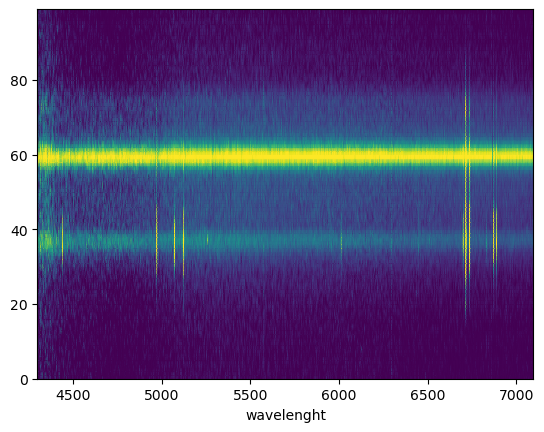

In [4]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [5]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0, 0.5, 'Flux [$10^{-16} erg/(cm^2 s \\AA )$]')

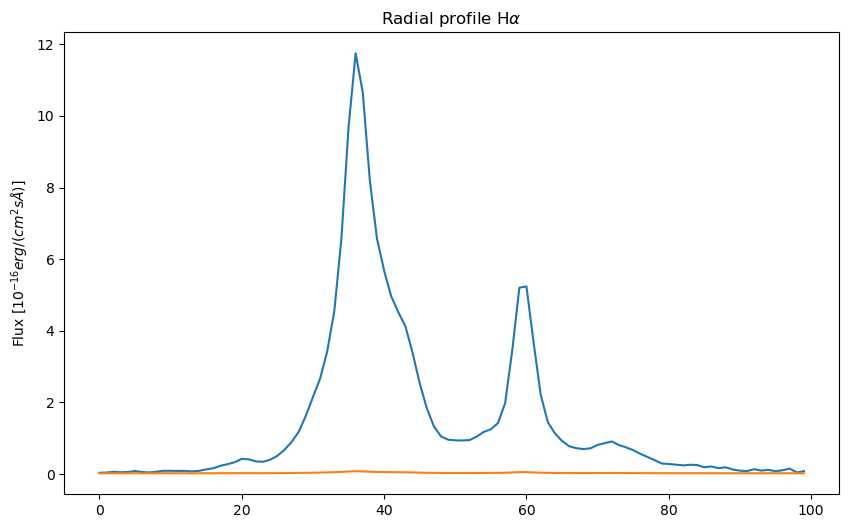

In [6]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'Radial profile H$\alpha$')
plt.ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')

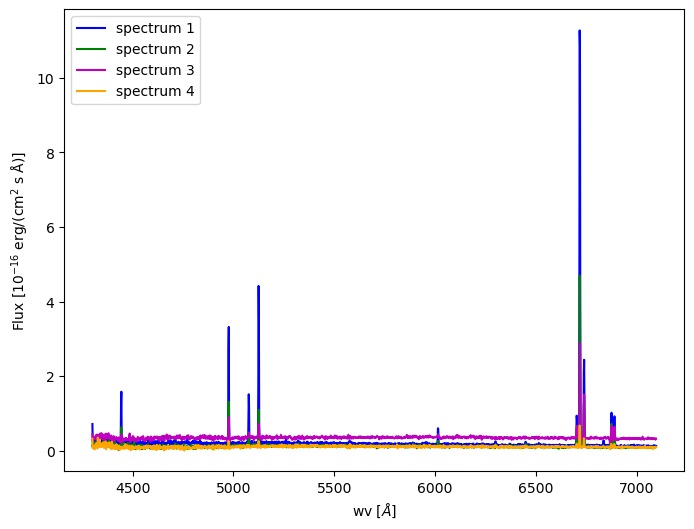

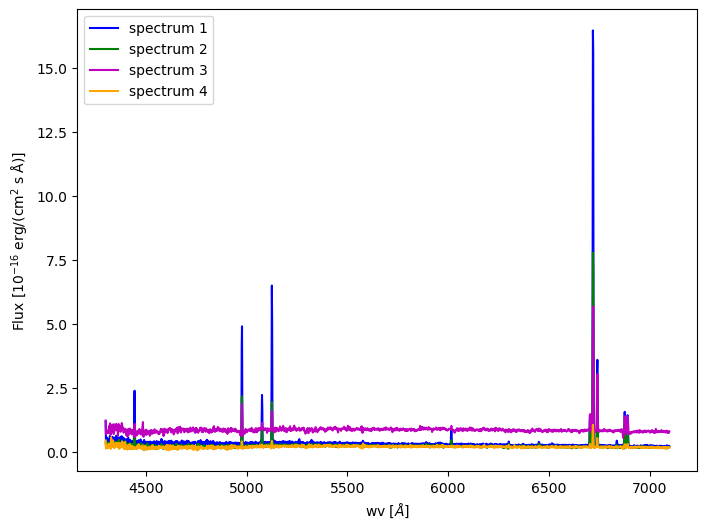

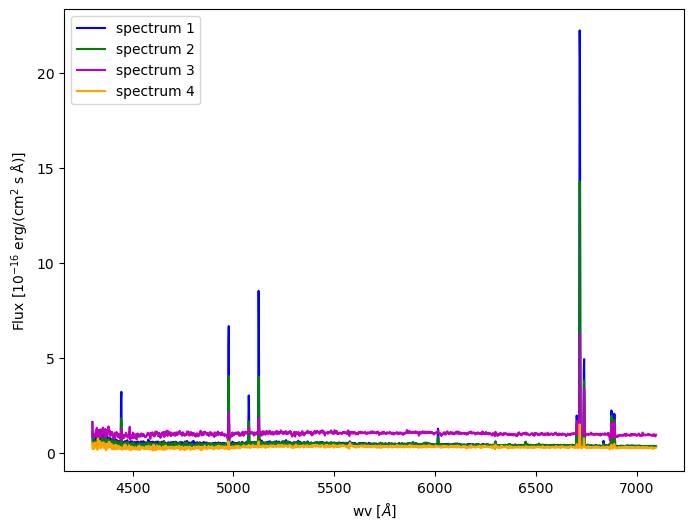

In [7]:
fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)
os.makedirs('1Sigma', exist_ok=True)
os.makedirs('2Sigma', exist_ok=True)
os.makedirs('3Sigma', exist_ok=True)

seeing = 3.174 #in pixels
sigma = seeing/2.35
peaks = fit_HA.iloc[3].values

plt.figure(figsize=(8,6))
spectra_1 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_1 = np.zeros((len(peaks), image_error_cut.shape[1]))
data1 = []
colors = ['blue', 'green', 'm', 'orange']
#Cut one sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-sigma)*(x_axes < peaks[i]+sigma)
    spectra_1[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_1[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_1[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_1[i].reshape(-1, 1), spectra_err_1[i].reshape(-1, 1)), axis=1)
    data1.append(spectrum_table)
    
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_1'), data1[0])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_2'), data1[1])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_3'), data1[2])
np.savetxt(os.path.join('1Sigma', 'Spectrum1s_4'), data1[3])

plt.figure(figsize=(8,6))
spectra_2 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_2 = np.zeros((len(peaks), image_error_cut.shape[1]))
data2 = []

#Cut two sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-2*sigma)*(x_axes < peaks[i]+2*sigma)
    spectra_2[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_2[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_2[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_2[i].reshape(-1, 1), spectra_err_2[i].reshape(-1, 1)), axis=1)
    data2.append(spectrum_table)
    
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_1'), data2[0])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_2'), data2[1])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_3'), data2[2])
np.savetxt(os.path.join('2Sigma', 'Spectrum2s_4'), data2[3])

plt.figure(figsize=(8,6))
spectra_3 =  np.zeros((len(peaks), image_cut.shape[1]))
spectra_err_3 = np.zeros((len(peaks), image_error_cut.shape[1]))
data3 = []
#Cut three sigma 
for i in range(len(peaks)):
    mask = (x_axes > peaks[i]-3*sigma)*(x_axes < peaks[i]+3*sigma)
    spectra_3[i] = np.sum(image_cut[mask, :], axis = 0)
    spectra_err_3[i] = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0)) #The error is the squared sum of the errors of each pixels (y) 
    plt.plot(wv, spectra_3[i], color = colors[i], label = f'spectrum {i+1}')
    plt.legend()
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra_3[i].reshape(-1, 1), spectra_err_3[i].reshape(-1, 1)), axis=1)
    data3.append(spectrum_table)
    
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_1'), data3[0])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_2'), data3[1])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_3'), data3[2])
np.savetxt(os.path.join('3Sigma', 'Spectrum3s_4'), data3[3])

## S/N continuum
Fare segnale/rumore per ogni pixel e poi fai la media, questo per le tre regioni

In [11]:
import pandas as pd

mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_1[i, mask_continuum_1]/spectra_err_1[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_2]/spectra_err_1[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_1[i, mask_continuum_3]/spectra_err_1[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('1Sigma', 'SNR_1s_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_2[i, mask_continuum_1]/spectra_err_2[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_2]/spectra_err_2[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_2[i, mask_continuum_3]/spectra_err_2[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('2Sigma', 'SNR_2s_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

SNR = []
for i in range(len(peaks)):  
    snr = []
    snr.append(np.mean(spectra_3[i, mask_continuum_1]/spectra_err_3[i, mask_continuum_1])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_2]/spectra_err_3[i, mask_continuum_2])) 
    snr.append(np.mean(spectra_3[i, mask_continuum_3]/spectra_err_3[i, mask_continuum_3])) 
    SNR.append(snr)

SNR_array = np.array(SNR).T  #Trasponi per avere continuum come righe

mean_continuum = np.mean(SNR_array, axis=0)

df = pd.DataFrame(SNR_array, 
                  columns=[f'Spettro_{i+1}' for i in range(4)],
                  index=['Continuum_1', 'Continuum_2', 'Continuum_3'])

df.loc['Mean_Continuum'] = mean_continuum

print(df)

df_path = os.path.join('3Sigma', 'SNR_3s_continuum.csv')
df.to_csv(df_path, float_format='%.3f')

                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      6.269747   3.258882  11.162513   2.832347
Continuum_2      9.288496   6.497236  17.447570   6.221620
Continuum_3      9.846644   7.219108  20.735319   7.321891
Mean_Continuum   8.468295   5.658409  16.448467   5.458619
                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      7.642982   4.488450  15.821598   3.686347
Continuum_2     11.597619   8.625527  25.585195   8.044665
Continuum_3     12.292858   9.561125  30.198015   9.399881
Mean_Continuum  10.511153   7.558368  23.868269   7.043631
                Spettro_1  Spettro_2  Spettro_3  Spettro_4
Continuum_1      8.745552   6.925408  16.348105   4.541581
Continuum_2     13.755333  12.556711  26.990404   9.998767
Continuum_3     14.702894  13.900606  31.895020  11.675143
Mean_Continuum  12.401259  11.127575  25.077843   8.738497


## S/N emission lines 

In [12]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [13]:
def SNR_line(wv, wv_line, spectra, peaks):
    left_region = (wv > wv_line-25)*(wv < wv_line-10) 
    right_region = (wv > wv_line+10)*(wv < wv_line+25) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))
    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
   # print(SNR)
   # print(Signal)
   # print(Noise)
    return SNR, Signal, Noise 

def SNR_HA_NII(wv, wv_line, spectra, peaks):
    left_region = (wv > 6675) & (wv < 6695)
    right_region = (wv > 6750) & (wv < 6775)
    clean_mask = left_region | right_region #But also for the two NII lines bc they are closed

    mask = (wv > wv_line-8)*(wv < wv_line+8)
    wv_bin = np.array(np.where(mask == True))

    Signal = []
    Noise = []
    SNR = []
    for i in range(len(peaks)):
        flux = spectra[i, mask] - np.mean(spectra[i, clean_mask])
        signal = (np.trapz(flux, wv[mask]))
        noise = np.std(spectra[i, clean_mask] - np.mean(spectra[i, clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
        SNR.append(signal/noise)
        Signal.append(signal)
        Noise.append(noise)
    return SNR, Signal, Noise 

In [14]:
SNR_HB_1, signal_HB_1, noise_HB_1 = SNR_line(wv, l_HB, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HB_1).reshape(-1, 1),
    np.array(signal_HB_1).reshape(-1, 1),
    np.array(noise_HB_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_HB_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_2, signal_HB_2, noise_HB_2 = SNR_line(wv, l_HB, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HB_2).reshape(-1, 1),
    np.array(signal_HB_2).reshape(-1, 1),
    np.array(noise_HB_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_HB_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HB_3, signal_HB_3, noise_HB_3 = SNR_line(wv, l_HB, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HB_3).reshape(-1, 1),
    np.array(signal_HB_3).reshape(-1, 1),
    np.array(noise_HB_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_HB_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_1, signal_SII_1, noise_SII_1 = SNR_line(wv, l_SII, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_SII_1).reshape(-1, 1),
    np.array(signal_SII_1).reshape(-1, 1),
    np.array(noise_SII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_SII_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_2, signal_SII_2, noise_SII_2 = SNR_line(wv, l_SII, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_SII_2).reshape(-1, 1),
    np.array(signal_SII_2).reshape(-1, 1),
    np.array(noise_SII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_SII_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_SII_3, signal_SII_3, noise_SII_3 = SNR_line(wv, l_SII, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_SII_3).reshape(-1, 1),
    np.array(signal_SII_3).reshape(-1, 1),
    np.array(noise_SII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_SII_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_1, signal_OIII_1, noise_OIII_1 = SNR_line(wv, l_OIII, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_OIII_1).reshape(-1, 1),
    np.array(signal_OIII_1).reshape(-1, 1),
    np.array(noise_OIII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_OIII_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_2, signal_OIII_2, noise_OIII_2 = SNR_line(wv, l_OIII, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_OIII_2).reshape(-1, 1),
    np.array(signal_OIII_2).reshape(-1, 1),
    np.array(noise_OIII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_OIII_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_OIII_3, signal_OIII_3, noise_OIII_3 = SNR_line(wv, l_OIII, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_OIII_3).reshape(-1, 1),
    np.array(signal_OIII_3).reshape(-1, 1),
    np.array(noise_OIII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_OIII_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_1, signal_HA_1, noise_HA_1 = SNR_HA_NII(wv, l_HA, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_HA_1).reshape(-1, 1),
    np.array(signal_HA_1).reshape(-1, 1),
    np.array(noise_HA_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_HA_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_2, signal_HA_2, noise_HA_2 = SNR_HA_NII(wv, l_HA, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_HA_2).reshape(-1, 1),
    np.array(signal_HA_2).reshape(-1, 1),
    np.array(noise_HA_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_HA_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_HA_3, signal_HA_3, noise_HA_3 = SNR_HA_NII(wv, l_HA, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_HA_3).reshape(-1, 1),
    np.array(signal_HA_3).reshape(-1, 1),
    np.array(noise_HA_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_HA_3s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_1, signal_NII_1, noise_NII_1 = SNR_HA_NII(wv, l_NII, spectra_1, peaks)
data = np.concatenate([
    np.array(SNR_NII_1).reshape(-1, 1),
    np.array(signal_NII_1).reshape(-1, 1),
    np.array(noise_NII_1).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('1Sigma', 'SNR_NII_1s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_2, signal_NII_2, noise_NII_2 = SNR_HA_NII(wv, l_NII, spectra_2, peaks)
data = np.concatenate([
    np.array(SNR_NII_2).reshape(-1, 1),
    np.array(signal_NII_2).reshape(-1, 1),
    np.array(noise_NII_2).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('2Sigma', 'SNR_NII_2s.csv')
df.to_csv(df_path, float_format='%.3f')

SNR_NII_3, signal_NII_3, noise_NII_3 = SNR_HA_NII(wv, l_NII, spectra_3, peaks)
data = np.concatenate([
    np.array(SNR_NII_3).reshape(-1, 1),
    np.array(signal_NII_3).reshape(-1, 1),
    np.array(noise_NII_3).reshape(-1, 1)], axis=1)
df = pd.DataFrame(data, columns=['SNR', 'Signal', 'Noise'],index = ['Component_1', 'Component_2', 'Component_3', 'Component_4'])
df_path = os.path.join('3Sigma', 'SNR_NII_3s.csv')
df.to_csv(df_path, float_format='%.3f')

## Redshift

In [8]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Numero di righe trovate: 10
   line_center    line_type line_center_index
     Angstrom                                
----------------- --------- -----------------
4444.299999999957  emission                97
  4977.0999999998  emission               457
5076.259999999771  emission               524
5125.099999999757  emission               557
6014.579999999494  emission              1158
6702.779999999291  emission              1623
6717.579999999287  emission              1633
 6739.77999999928  emission              1648
 6875.93999999924  emission              1740
6889.259999999236  emission              1749
Numero di righe trovate: 10
   line_center    line_type line_center_index
     Angstrom                                
----------------- --------- -----------------
4442.819999999958  emission                96
  4977.0999999998  emission               457
5076.259999999771  emission               524
5125.099999999757  emission               557
6014.579999999494  emiss

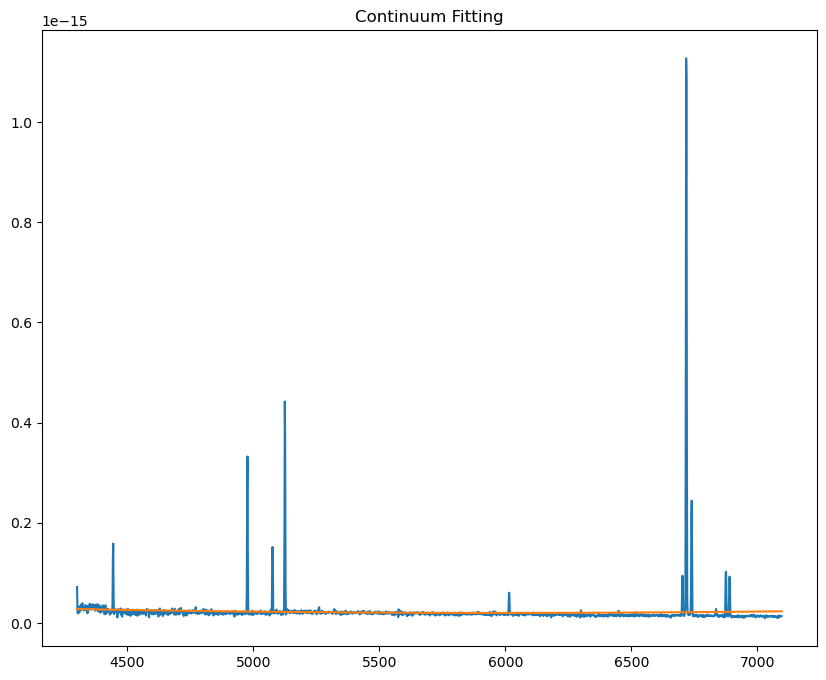

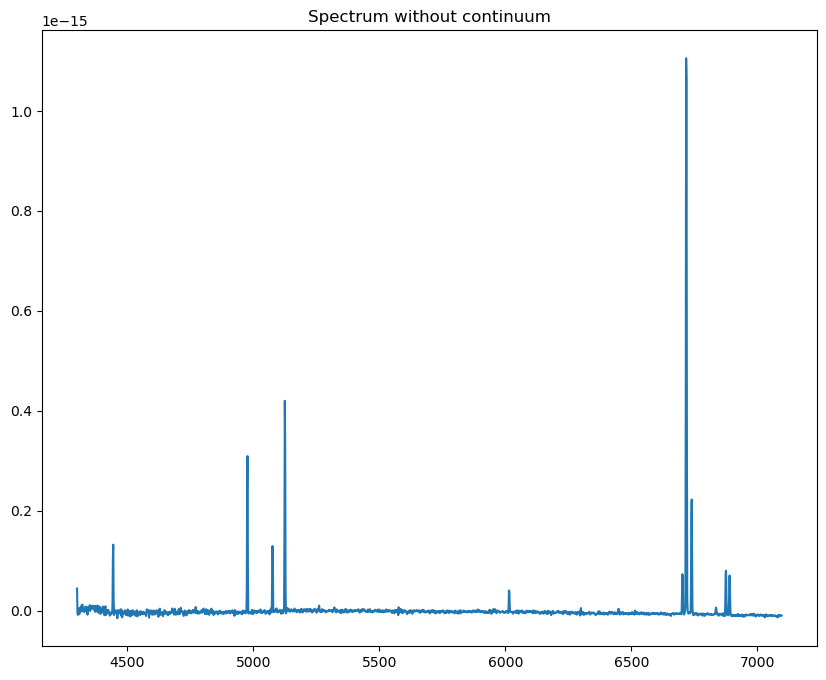

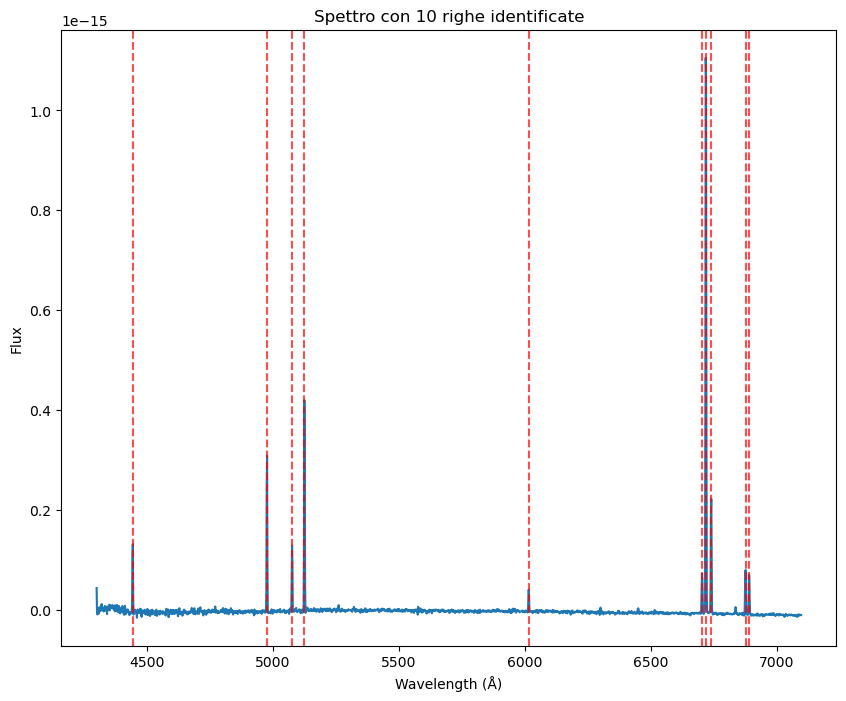

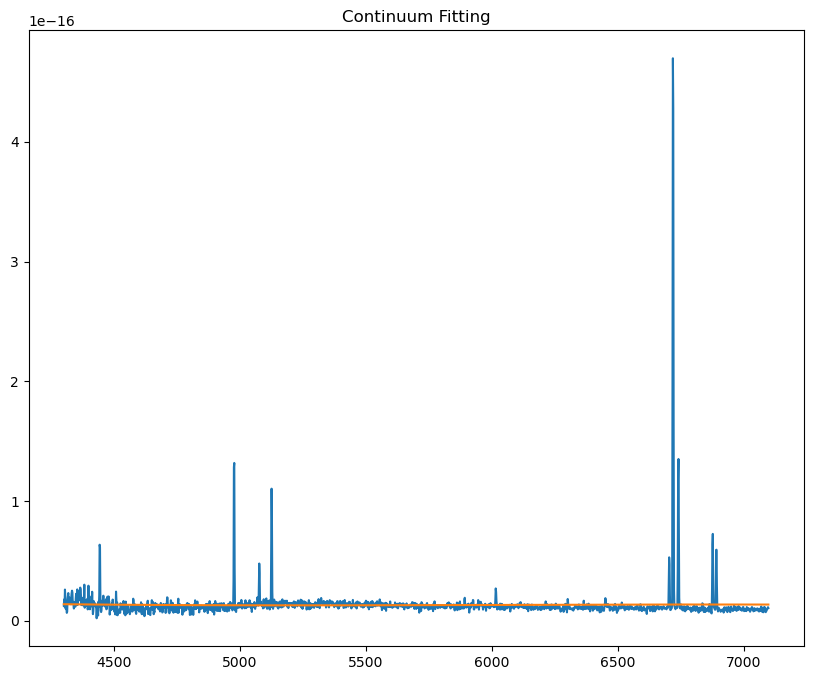

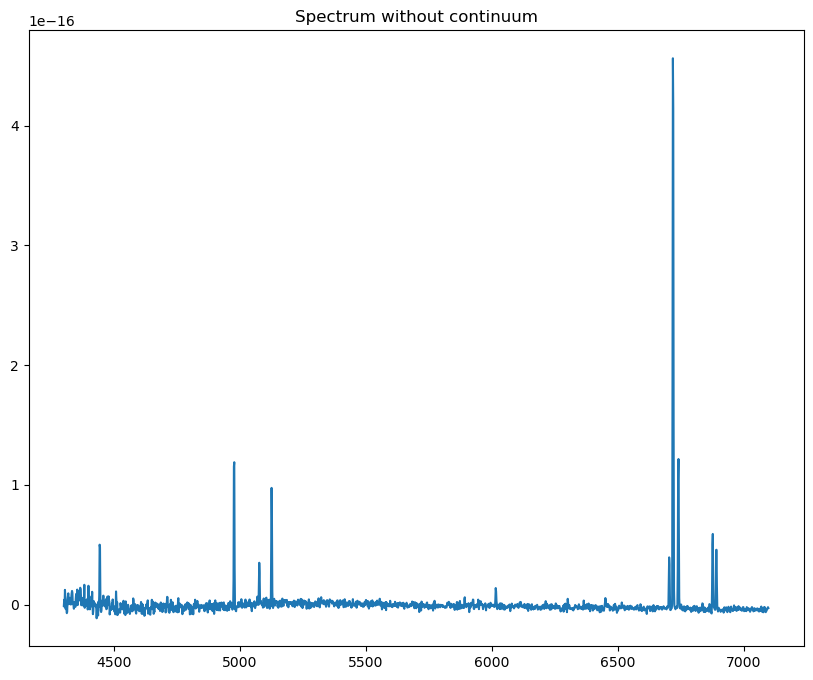

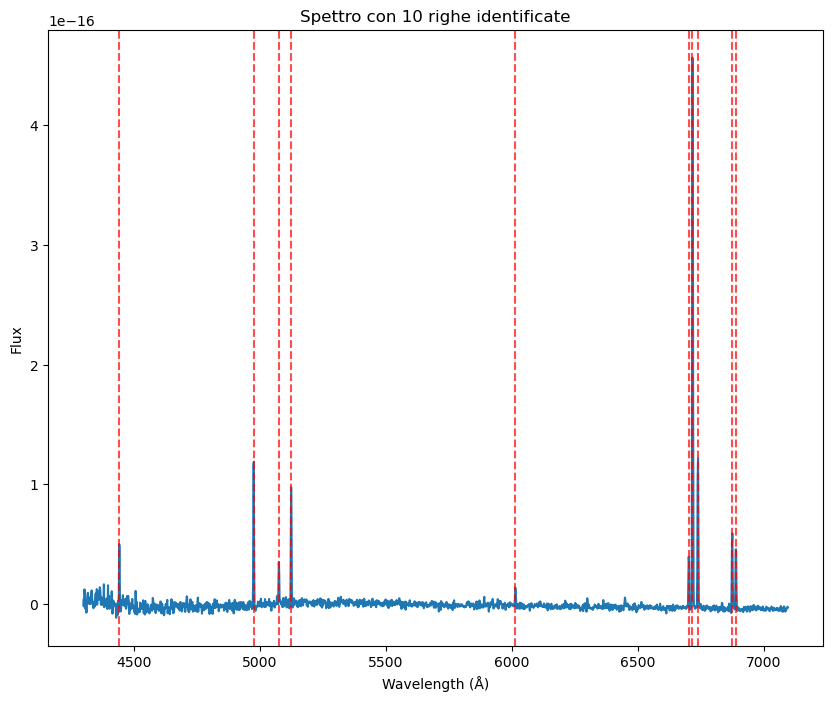

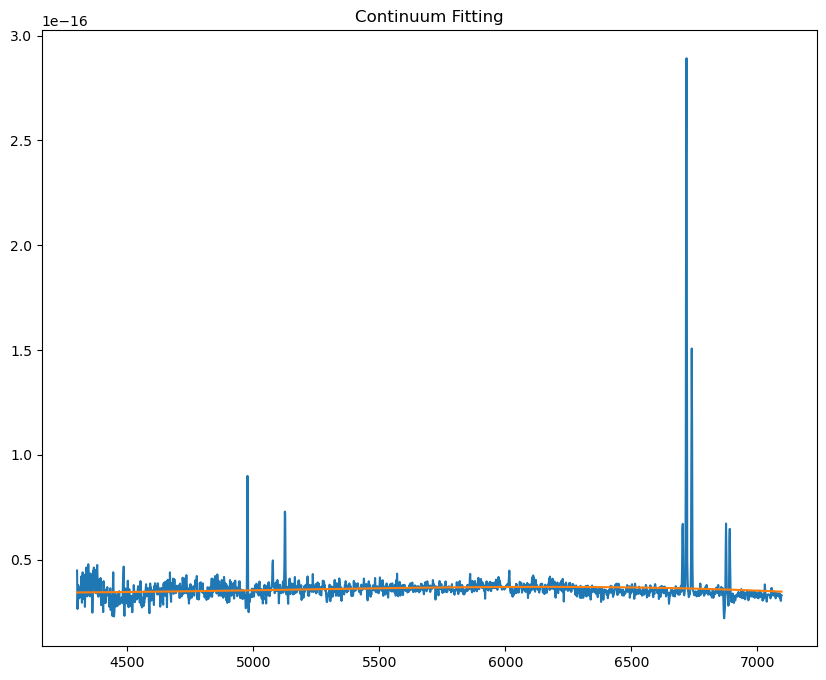

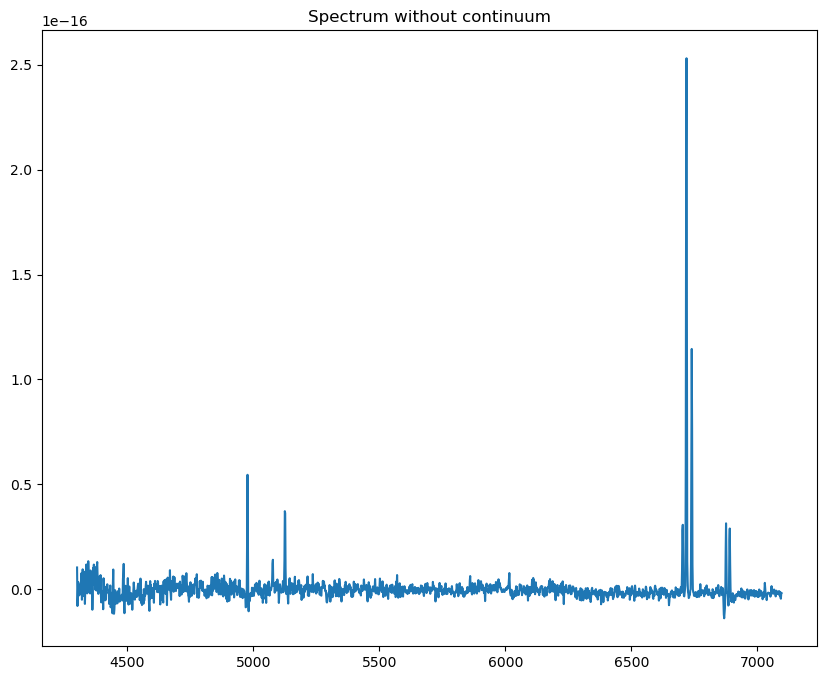

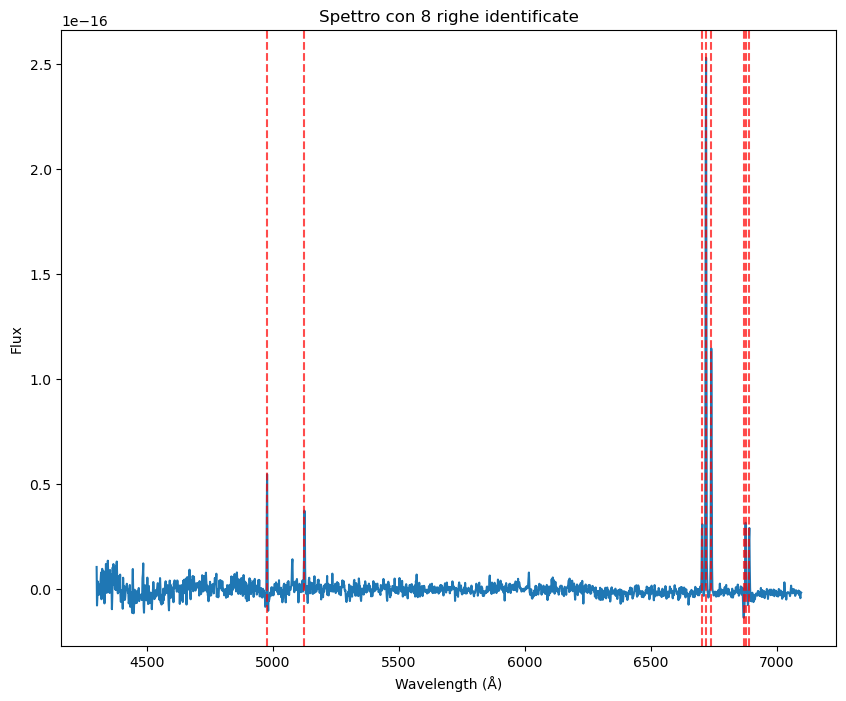

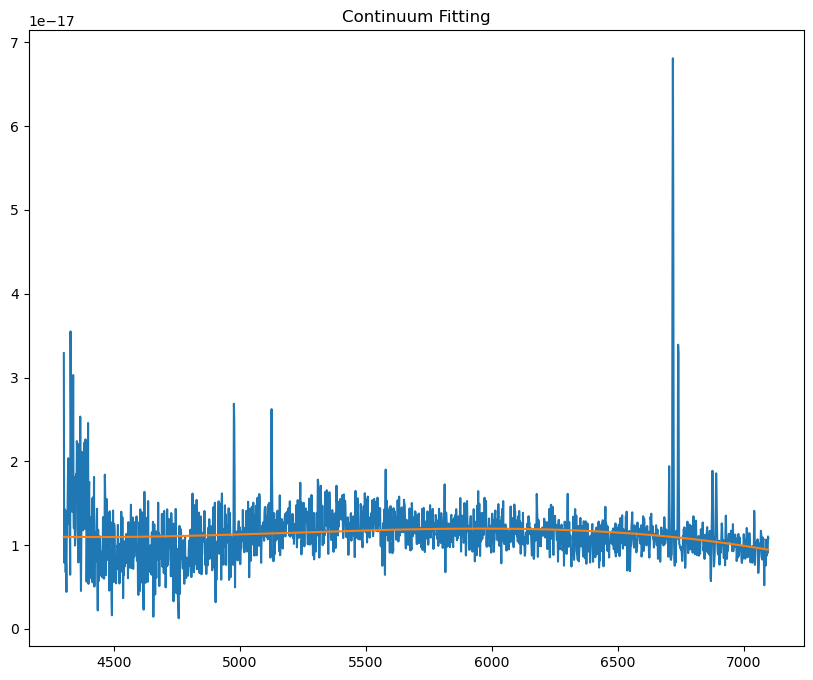

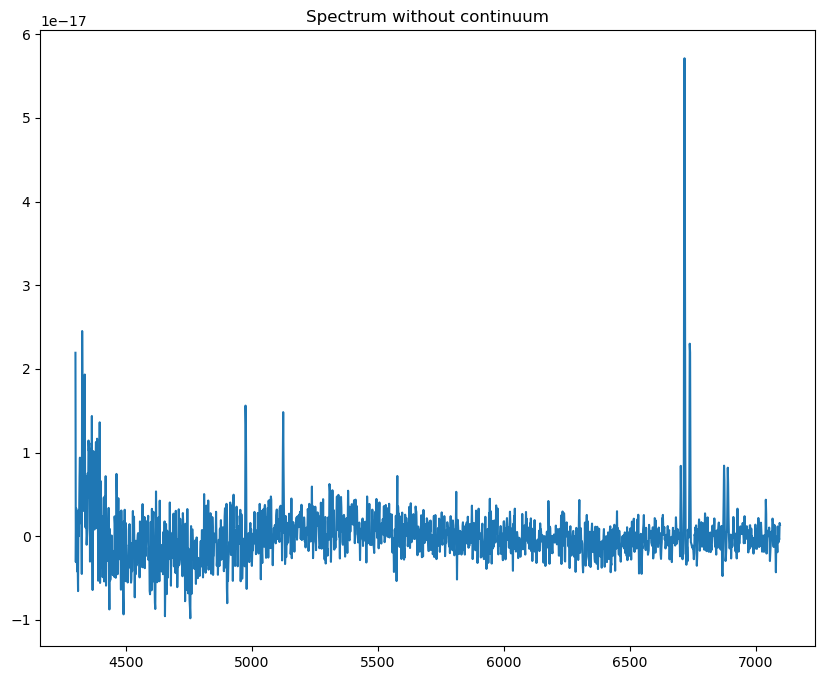

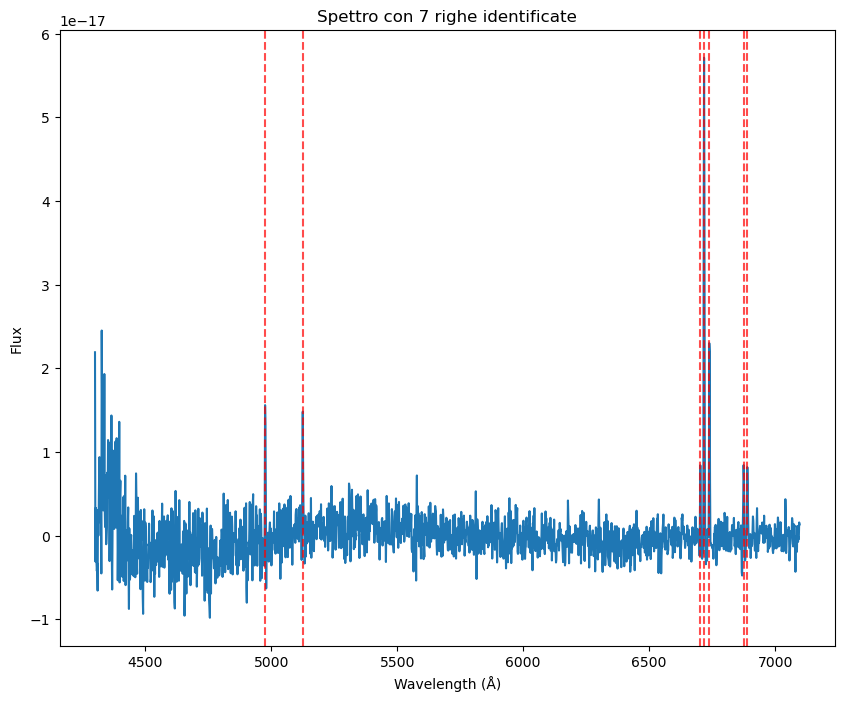

In [9]:
all_lines = []
noise_factor = [11, 7, 6, 4.5]
for i in range(len(peaks)):
    spectrum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux = spectra_1[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_1[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv * u.Angstrom)
    f, ax = plt.subplots(figsize = (10,8))
    ax.plot(wv * u.Angstrom, spectra_1[i]* 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    ax.plot(wv * u.Angstrom, y_continuum_fitted)
    ax.set_title("Continuum Fitting")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    f2, ax2 = plt.subplots(figsize = (10,8))
    ax2.plot(wv * u.Angstrom, flux_continuum_subtracted)
    
    ax2.set_title("Spectrum without continuum")
    spectrum_no_continuum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux=flux_continuum_subtracted,
        uncertainty=StdDevUncertainty(spectra_err_1[i] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    lines = find_lines_threshold(spectrum_no_continuum, noise_factor = noise_factor[i])
    print(f"Numero di righe trovate: {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            ax3.axvline(x=line_pos.value, color='r', alpha=0.7, linestyle='--')
    
    ax3.set_title(f"Spettro con {len(lines)} righe identificate")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [11]:
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_1 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_1 = all_lines[0]['line_center'] 
lines_spectrum_2 = all_lines[1]['line_center']

z_1 = np.zeros(len(lines_spectrum_1))
z_2 = np.zeros(len(lines_spectrum_2))

for i in range(len(lines_spectrum_1)):
    z_1[i] = lines_spectrum_1[i].value / lines_1[i] - 1
    z_2[i] = lines_spectrum_2[i].value / lines_1[i] - 1
print(np.mean(z_1))
print(np.std(z_1))
print(np.mean(z_2))
print(np.std(z_2))

lines_3 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_3 = all_lines[2]['line_center'] 
z_3 = np.zeros(len(lines_spectrum_3)-1)

for i in range(len(lines_spectrum_3)-1):
    z_3[i] = lines_spectrum_3[i].value / lines_3[i] - 1
print(np.mean(z_3))
print(np.std(z_3))

lines_4 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_spectrum_4 = all_lines[3]['line_center'] 
z_4 = np.zeros(len(lines_spectrum_4))

for i in range(len(lines_spectrum_4)):
    z_4[i] = lines_spectrum_4[i].value / lines_4[i] - 1
print(np.mean(z_4))
print(np.std(z_4))

0.023677233401117336
0.00011917819433985641
0.02366512278451638
7.130116905423882e-05
0.023744163800112572
7.987657320658472e-05
0.02354116504859194
6.77371116356793e-05
